In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

plt.rcParams.update({"font.size": 16})

import helper

/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:106: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = windows.dot(grn)
/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:129: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = gene_vals.dot(internal_grn)


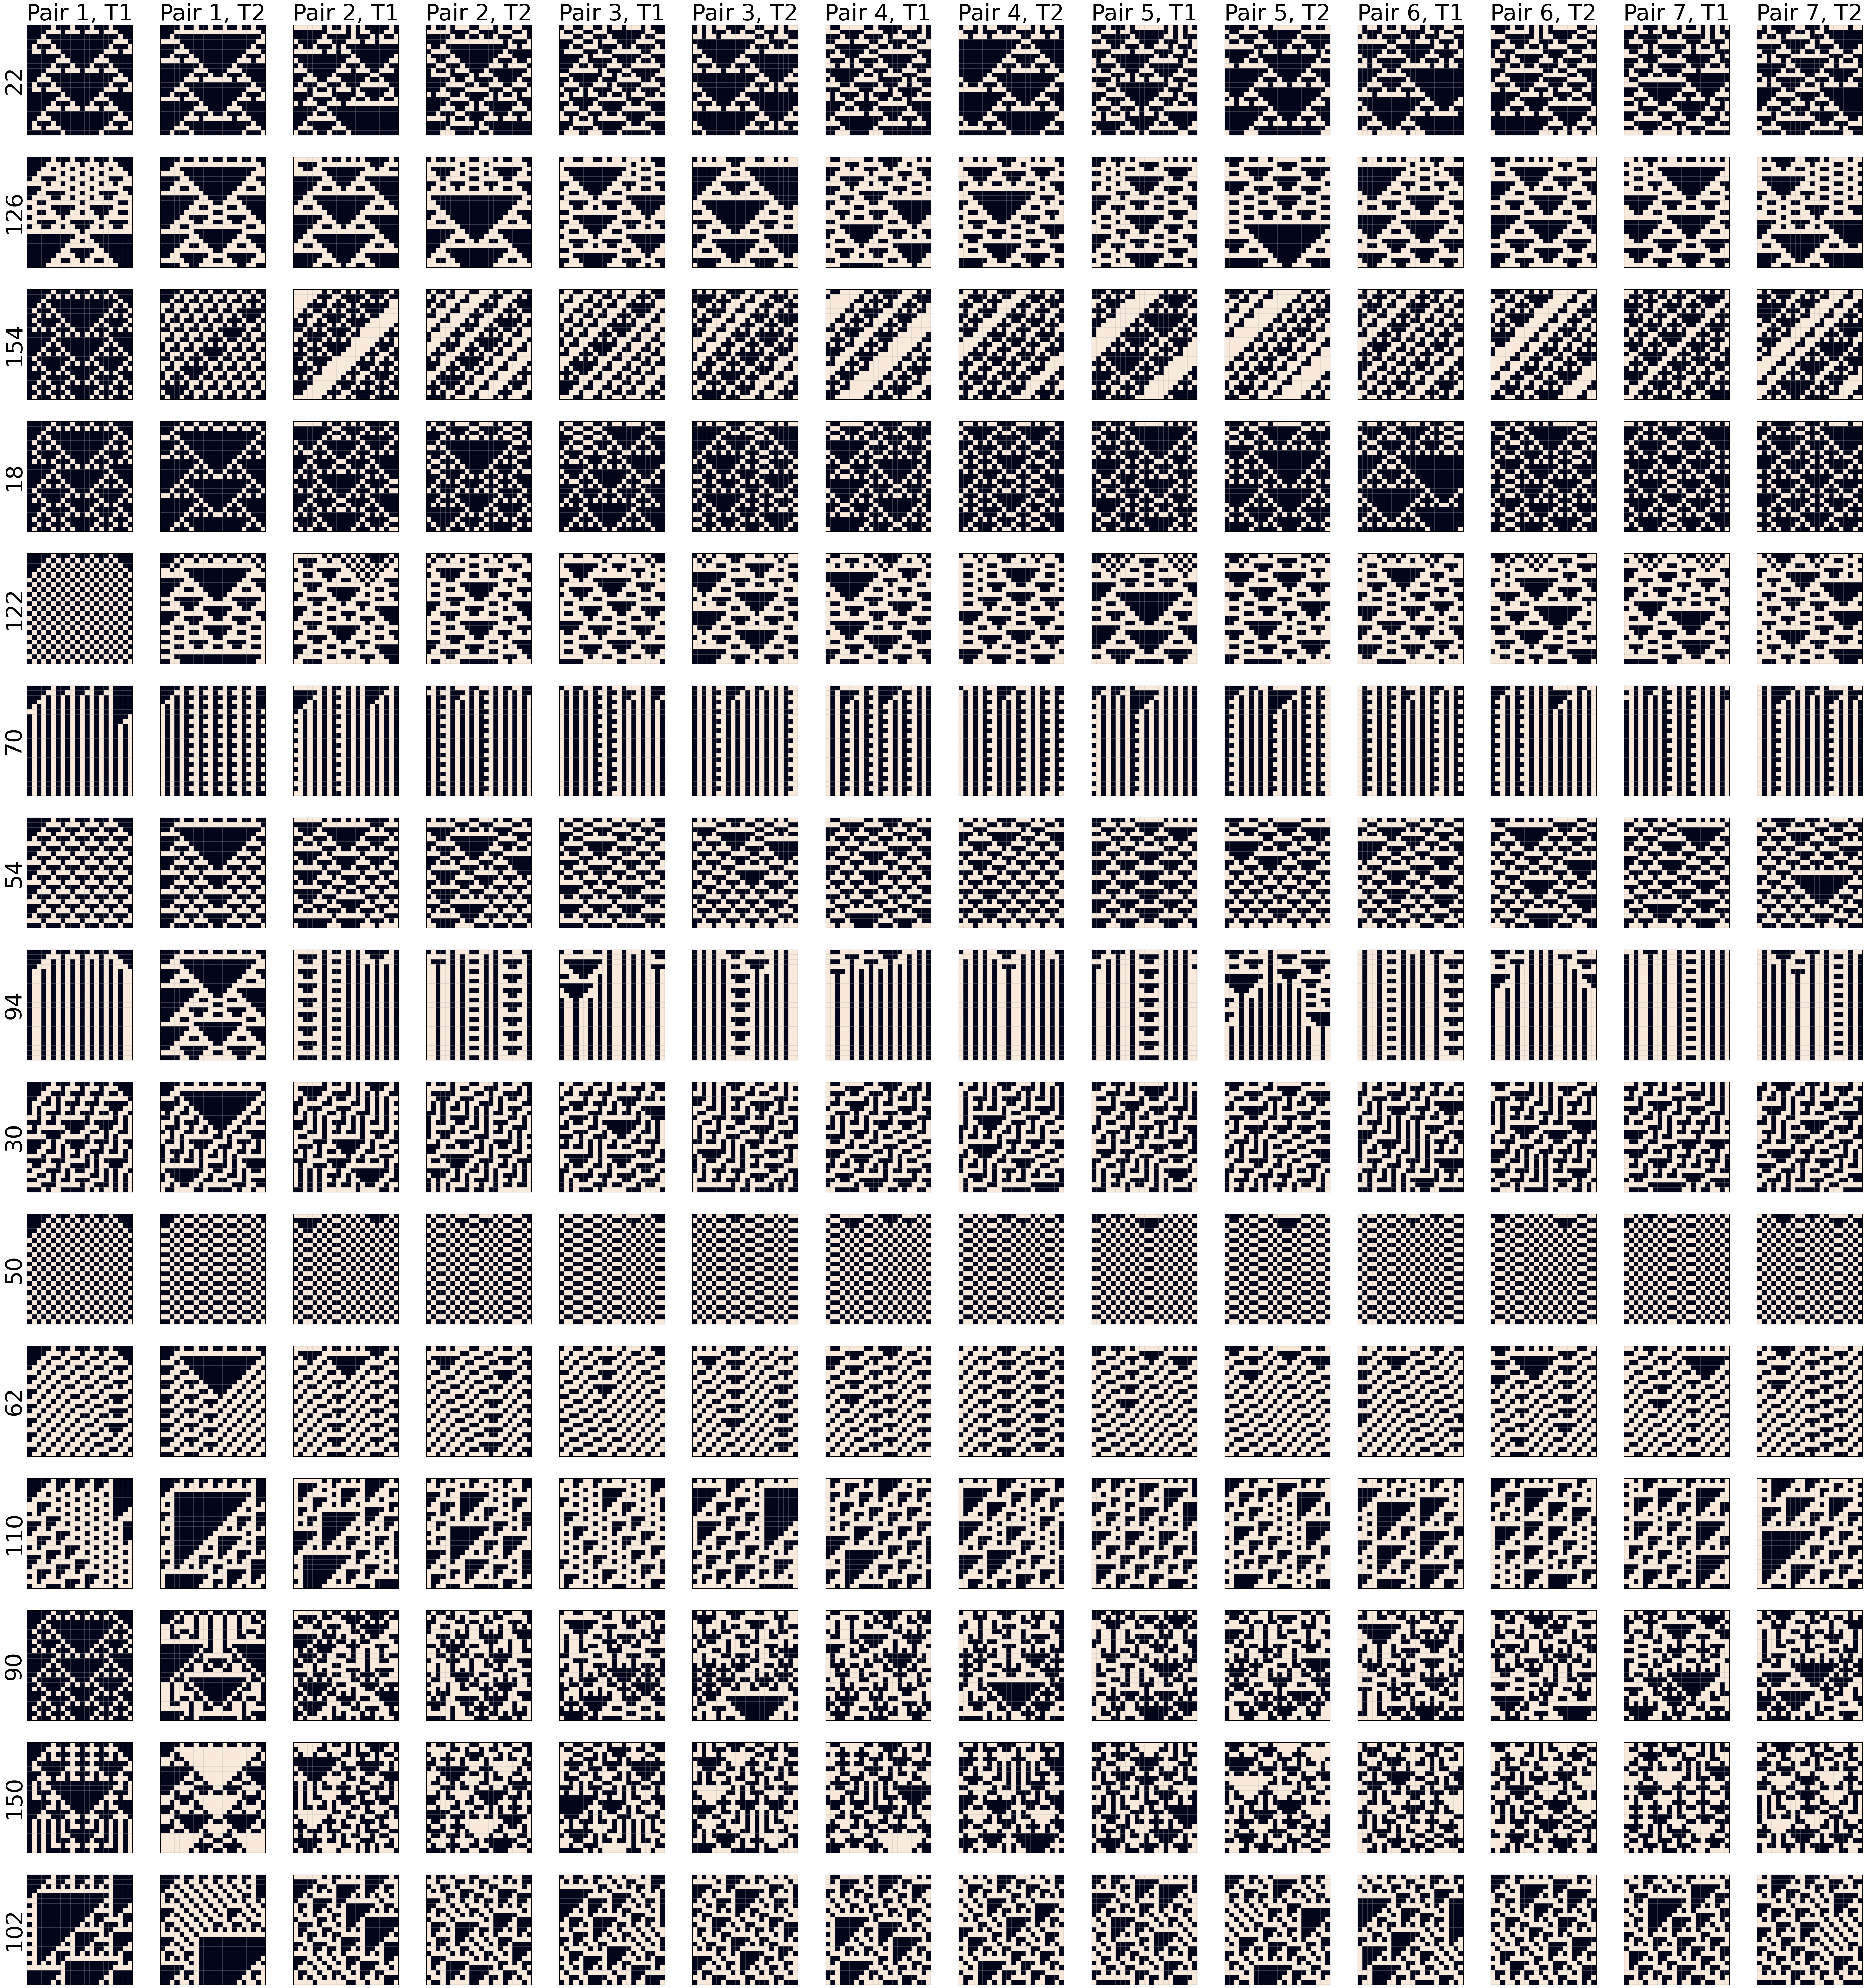

In [2]:
#Target CA patterns

rules = [22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]
seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]

#Make example population
pop_size = 1000
grn_size = 22
num_cells = 22
dev_steps = 22
geneid = 1
pop = np.random.randn(pop_size, grn_size+2, grn_size).astype(np.float64)

ts=[]
for rule in rules:
    for seed in seed_intss:
        targets1, phenos, fitnesses1 = helper.get_pop_TPF(pop, pop_size, num_cells, grn_size, dev_steps, geneid, rule, seed[0],seed[0])
        targets2, phenos, fitnesses2 = helper.get_pop_TPF(pop, pop_size, num_cells, grn_size, dev_steps, geneid, rule, seed[1],seed[1])
        ts.append([targets1, targets2])
        
#Make supp figure with all targets
ncols=14
nrows=15 
scale=5
fig, axs = plt.subplots(figsize=(ncols * scale, nrows * scale), ncols=ncols, nrows=nrows)
axs=axs.flatten()

targs=np.array(ts).reshape(ncols*nrows,23,22)
rc=0
tc=1
for idx, a in enumerate(axs):
    im = helper.imshow_ca(targs[idx], ax=a)
    if idx % 14 == 0:
        a.set_ylabel(rules[rc], fontsize=48)
        rc+=1
    if idx < 14:
        if idx % 2 == 0:
            a.set_title(f"Pair {tc}, T1", fontsize=48)
        else:
            a.set_title(f"Pair {tc}, T2", fontsize=48)
            tc+=1

plt.savefig("figs/suppfig_6.pdf", format="pdf", bbox_inches="tight")

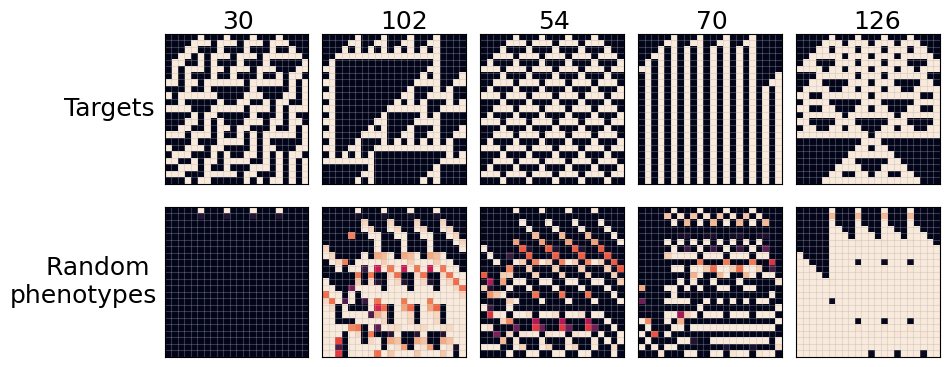

In [3]:
#Random GRN phenotypes

seed_ints = [69904,149796]

fig, axs = plt.subplots(
    2, 5, figsize=(10, 6), sharex=True, sharey=True
)
rules_plot = [30,102,54,70,126,154,94,62,150,102]
axss=axs.flatten()

np.random.seed(42)
pop = np.random.randn(pop_size, grn_size+2, grn_size).astype(np.float64)

c=0
for i, rule in enumerate(rules_plot):
    targets, phenos, fitnesses = helper.get_pop_TPF(pop, pop_size, num_cells, grn_size, dev_steps, geneid, rule, seed_ints[0],seed_ints[0])
    if c<5: #i%2==0:
        helper.imshow_ca(targets, ax=axss[i])
        axss[i].text(0.4, 1.08, rule, transform=axss[i].transAxes, va='center', ha='left', fontsize=18)
        if c == 0:
            axss[i].text(-0.7, 0.5, "Targets", transform=axss[i].transAxes, va='center', ha='left', fontsize=18)

    else:
        helper.imshow_ca(phenos[i+110,:,:], ax=axss[i])
        if c == 5:
            axss[i].text(-0.05, 0.5, "Random \nphenotypes", transform=axss[i].transAxes, va='center', ha='right', fontsize=18)

    c+=1

plt.subplots_adjust(hspace=-0.4, wspace=0.1)
plt.savefig('figs/suppfig_1A.pdf', format='pdf', bbox_inches="tight")

In [4]:
#Distribution of fitnesses of random GRNs

rules=[30, 50, 54, 70, 22, 126, 154, 18, 122,94,62,110,90,150,102]
rules_plot = [30,50,54,70,126,154,94,62,150,102]
seed_ints = [69904,149796]
root="~/CA_GRN_results/detailed_save/"

fits=[]
avs = []
for rule in rules_plot:
    targets, calc_phenos, calc_fitnesses = helper.get_pop_TPF(pop, pop_size, num_cells, grn_size, dev_steps, geneid, rule, seed_ints[0],seed_ints[0])
    maxs=[np.loadtxt(os.path.expanduser(root+f"static/stats_100000_{rule}_{seed_ints[0]}_{i+1}_maxfits.txt")) for i in range(15)]
    avs.append(np.array(maxs)[:,-1].mean())
    fits.append(calc_fitnesses)


/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as

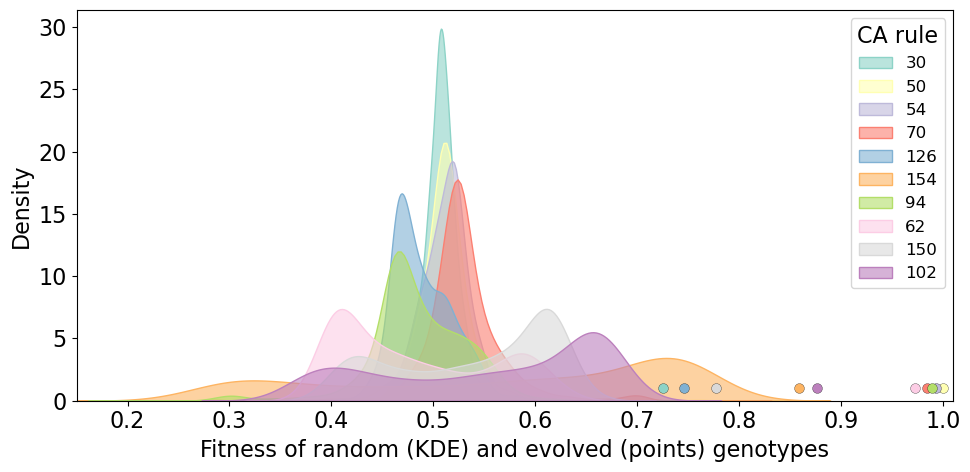

In [5]:
colors = sns.color_palette("Set3", len(rules_plot))

plt.figure(figsize=(10, 5)) 

c=0
for idx, data in enumerate(fits):
    sns.kdeplot(data, fill=True,label=rules_plot[idx],color=colors[c],alpha=0.6)
    plt.scatter(avs[c], 1, color=colors[c], s=50, zorder=3,edgecolors="black", linewidths=0.2)  # Adjust `s` for dot size
    c+=1
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(title="CA rule", ncol=1,loc="upper right",fontsize = 12)
plt.xlim(0.15,1.01)
plt.xlabel("Fitness of random (KDE) and evolved (points) genotypes")
plt.tight_layout()
plt.savefig('figs/suppfig_1B.pdf', format='pdf', bbox_inches="tight")

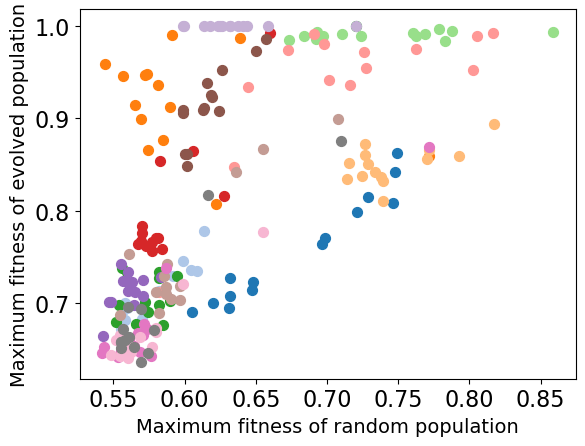

In [10]:
#Comparing random GRNs to evolved fitnesses across rules and initial condition pairs

root1="~/CA_GRN_results/detailed_save/"
root2="~/CA_GRN_results/non_detailed_save/"
root3="~/CA_GRN_results/non_detailed_save/extra_inputs/"
season_len = 100_000 #static experiments
seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
#metric = "avefits" #repeat for "maxfits"
metric = "maxfits"
num_reps = 15
id_start = 0

pop_size = 1000
grn_size = 22
num_cells = 22
dev_steps = 22
geneid = 1

pop = np.random.randn(pop_size, grn_size+2, grn_size).astype(np.float64)
rules=[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

colors = sns.color_palette("tab20", len(rules))

c=0
all_avs=[]
all_rand=[]
for rule in rules:
     avs=[]
     rand=[]
     for si in seed_intss:
          for s in si:
               targets, phenos, fitnesses = helper.get_pop_TPF(pop, pop_size, num_cells, grn_size, dev_steps, geneid, rule, s,s)
               if s == 69904 or s == 149796:
                    root = root1
               elif s== 4147842 or s == 1238860:
                    root = root2
               else:
                    root = root3
               maxs=[np.loadtxt(os.path.expanduser(root+f"static/stats_{season_len}_{rule}_{s}_{i+1+id_start}_{metric}.txt")) for i in range(num_reps)]
               avs.append(np.array(maxs)[:,-1].mean())
               all_avs.append(np.array(maxs)[:,-1].mean())
               #rand.append(fitnesses.mean())
               #all_rand.append(fitnesses.mean())
               rand.append(fitnesses.max())
               all_rand.append(fitnesses.max())
    
     plt.scatter(rand, avs, color=colors[c],label=rule,s=50)
     
     c+=1
#plt.ylabel("Average fitness of evolved population", fontsize=14)
#plt.xlabel("Average fitness of random population", fontsize=14)
plt.ylabel("Maximum fitness of evolved population", fontsize=14)
plt.xlabel("Maximum fitness of random population", fontsize=14)
plt.savefig('figs/suppfig_2B.pdf', format='pdf', bbox_inches="tight")

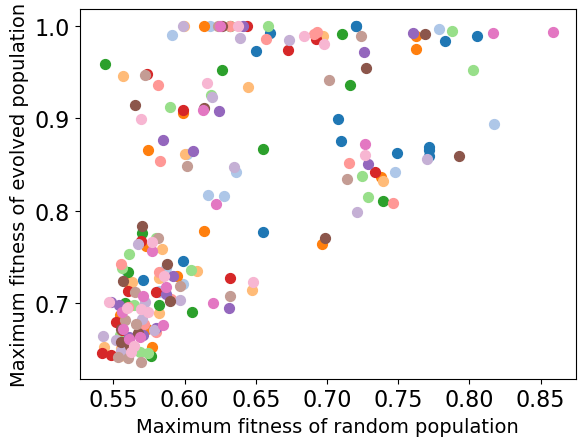

In [13]:
root1="~/CA_GRN_results/detailed_save/"
root2="~/CA_GRN_results/non_detailed_save/"
root3="~/CA_GRN_results/non_detailed_save/extra_inputs/"
season_len = 100_000
seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
#metric = "avefits"
metric = "maxfits"
num_reps = 15
id_start = 0

pop_size = 1000
grn_size = 22
num_cells = 22
dev_steps = 22
geneid = 1

rules=[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

colors = sns.color_palette("tab20", len(rules))

c=0

for si in seed_intss:
    for s in si:
        avs=[]
        rand=[]
        for rule in rules:
               targets, phenos, fitnesses = helper.get_pop_TPF(pop, pop_size, num_cells, grn_size, dev_steps, geneid, rule, s,s)
               if s == 69904 or s == 149796:
                    root = root1
               elif s== 4147842 or s == 1238860:
                    root = root2
               else:
                    root = root3
               maxs=[np.loadtxt(os.path.expanduser(root+f"static/stats_{season_len}_{rule}_{s}_{i+1+id_start}_{metric}.txt")) for i in range(num_reps)]
               avs.append(np.array(maxs)[:,-1].mean())
               #all_avs.append(np.array(maxs)[:,-1].mean())
               #rand.append(fitnesses.mean())
               rand.append(fitnesses.max())
               #all_rand.append(fitnesses.max())
    
        plt.scatter(rand, avs, color=colors[c],label=rule,s=50)
     
        c+=1
#plt.ylabel("Average fitness of evolved population", fontsize=14)
#plt.xlabel("Average fitness of random population", fontsize=14)
plt.ylabel("Maximum fitness of evolved population", fontsize=14)
plt.xlabel("Maximum fitness of random population", fontsize=14)
plt.savefig('figs/suppfig_2D.pdf', format='pdf', bbox_inches="tight")

In [11]:
import pandas as pd
params = [item for pair in seed_intss for item in pair]  # Flattened to 14 values

rules_column = [rule for rule in rules for _ in range(14)]
params_column = params * 15  # Repeat the inner loop values 15 times, for the rules

# Construct the DataFrame
df = pd.DataFrame({
    'rule': rules_column,
    'param': params_column,
    'value': all_avs
})

df['rule'] = df['rule'].astype('category')
df['param'] = df['param'].astype('category')

In [12]:
stds=[]
for r in rules:
    t = df[df["rule"]==r].value.to_list()
    stds.append(np.array(t).std())
print("rules:", sum(stds)/len(stds))
r_std=sum(stds)/len(stds)

stds=[]
for p in params:
    t = df[df["param"]==p].value.to_list()
    stds.append(np.array(t).std())
print("init conds:", sum(stds)/len(stds))
i_std=sum(stds)/len(stds)

#Initial condition standard deviation / CA rules standard deviation
i_std/r_std

rules: 0.044877597468370424
init conds: 0.13205859544008963


2.942639599483107